# Deep Reinforcement Learning Class Spring 2026 Assignment 3 Q1

This is the first part of the assignment. In this part, you will learn DQN and its variants with the AcroBot environment from OpenAI Gym.

You need to fill in the missing code snippets (marked by TODO). Feel free to modify the code structure based on your understanding, but **you are forbidden to use any external RL libraries like Stable Baselines3**, **RLlib**, etc.

Make a copy of this notebook using File > Save a copy in Drive and edit it with your answers.

WARNING: Do not put your name or any other personal identification information in this notebook.

## Question 1-1: Random Agent (5%)

We will start by loading AcroBot environment and creating a random agent.

First, install the required packages and import the necessary libraries.

In [1]:
# !pip install gymnasium
# !pip install imageio

In [1]:
import os
import random
from collections import deque

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import ExponentialLR
import matplotlib.pyplot as plt
from IPython.display import Image, display
import imageio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
### Understanding the AcroBot Environment

The Acrobot is a two-link underactuated robot, analogous to a gymnast swinging on a high bar. The system consists of two rigid links connected by actuated joints, with the first link fixed to a pivot point. The control objective is to swing the endpoint of the second link above a specified height.

#### State Space

The observation is a 6-dimensional continuous vector:

| Index | Variable | Description | Range |
|-------|----------|-------------|-------|
| 0 | $\cos(\theta_1)$ | Cosine of angle of link 1 | $[-1, 1]$ |
| 1 | $\sin(\theta_1)$ | Sine of angle of link 1 | $[-1, 1]$ |
| 2 | $\cos(\theta_2)$ | Cosine of angle of link 2 | $[-1, 1]$ |
| 3 | $\sin(\theta_2)$ | Sine of angle of link 2 | $[-1, 1]$ |
| 4 | $\dot{\theta}_1$ | Angular velocity of link 1 | $[-4\pi, 4\pi]$ |
| 5 | $\dot{\theta}_2$ | Angular velocity of link 2 | $[-9\pi, 9\pi]$ |

#### Action Space

The agent can apply one of three discrete torques to the joint between the two links:

| Action | Torque |
|--------|--------|
| 0 | $-1$ (negative torque) |
| 1 | $0$ (no torque) |
| 2 | $+1$ (positive torque) |

#### Reward Structure

- The agent receives a reward of $-1$ for each timestep until termination
- Episode terminates when the tip reaches the target height, or after 500 steps (truncation)

More information about this environment can be found [here](https://gymnasium.farama.org/environments/classic_control/acrobot/)

In [3]:
env = gym.make("Acrobot-v1", render_mode="rgb_array")

print("Environment Specifications:")
print(f"  Observation space: {env.observation_space}")
print(f"  Action space: {env.action_space}")
print(f"  Max episode steps: {env.spec.max_episode_steps}")

obs, info = env.reset(seed=42)
print(f"\nSample observation: {obs}")
print(f"Observation dtype: {obs.dtype}")

Environment Specifications:
  Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
  Action space: Discrete(3)
  Max episode steps: 500

Sample observation: [ 0.99849933  0.0547638   0.99992526 -0.01222401  0.07171959  0.0394736 ]
Observation dtype: float32


### Implementing the Random Agent (5%)

We will implement a random agent that selects actions randomly from the action space of the environment. Random agents are useful for testing the environment and ensuring that it is working as expected.

Total reward: -500.0


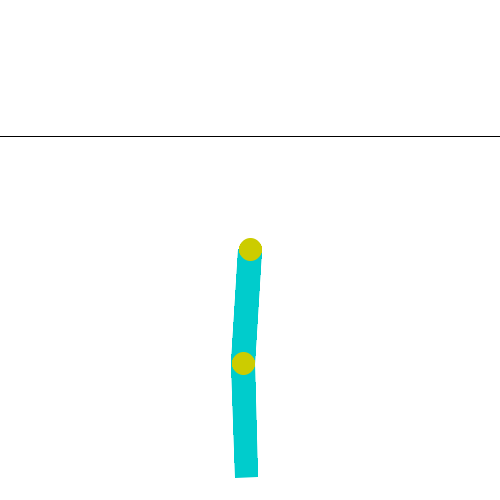

In [4]:
frames = [] # Store the frames for the animation

observation, _ = env.reset()
done = False
total_reward = 0
while not done:
    # TODO: Select an action randomly
    action = env.action_space.sample()

    # TODO: Take a step in the environment
    # observation, reward, terminated, truncated, info = ...
    observation, reward, terminated, truncated, info = env.step(action)

    # TODO: Check if the episode is done
    done = terminated or truncated

    # TODO: Update the total reward
    total_reward += reward

    frames.append(env.render()) # Save the frame for the animation

env.close()
print("Total reward:", total_reward)

# Visulization
### Do not modify the follwing code—any changes will result in a score of 0 for this question.
gif_path = "random_agent.gif"
imageio.mimsave(gif_path, frames, fps=30)
display(Image(filename=gif_path))

---
## Question 1-2: DQN Agent (10%)

Next, we will implement a Deep Q-Networks (DQN) agent that learns to play the AcroBot-v1 game. DQN is a reinforcement learning algorithm that uses a deep neural network to approximate the Q-function, allowing the agent to estimate the expected future rewards for each action and learn an optimal policy.

In this question, we will:

1. Define a neural network model to approximate the Q-function.
2. Implement the experience replay buffer to store past experiences.
3. Implement the DQN agent that interacts with the environment, updates the network, and learns to play the game.

By completing this section, you will build the core components of a DQN-based reinforcement learning agent that can successfully land the spacecraft in the AcroBot-v1 environment! 🚀

### Defining the Neural Network Model

In [2]:
class QNetwork(nn.Module):
    """
    Q-Network implemented as a multi-layer perceptron.

    Args:
        obs_dim: Dimension of observation space
        action_dim: Number of discrete actions
        hidden_dim: Number of hidden units per layer
    """

    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 64):
        super().__init__()
        # TODO: Define the network architecture
        self.network = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Compute Q-values for all actions.

        Args:
            x: State tensor of shape (batch_size, obs_dim)

        Returns:
            Q-values of shape (batch_size, action_dim)
        """
        return self.network(x)

### Implementing the Experiment Replay Buffer

In [3]:
class ReplayBuffer:
    """
    Fixed-size circular buffer for storing experience tuples.

    Stores transitions (s, a, r, s', done) and supports uniform random sampling.

    Args:
        capacity: Maximum number of transitions to store
    """

    # TODO: Initialize the buffer data structure
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    # TODO: Implement the push method
    def push(self, state, action, reward, next_state, done):
        """Add a transition to the buffer."""
        self.buffer.append((state, action, reward, next_state, done))

    # TODO: Implement the sample method
    def sample(self, batch_size: int):
        """Sample a batch of transitions uniformly at random."""
        transitions = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*transitions)

        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

### Defining the DQN Agent

In [4]:
class DQNAgent:
    """
    Deep Q-Network agent.

    Implements the DQN algorithm with experience replay and target network.

    Args:
        config: Dictionary containing hyperparameters
    """

    def __init__(self):
        # TODO: Initialize some parameters, networks, optimizer, and replay buffer
        self.batch_size = 128
        self.gamma = 0.99
        self.lr = 5e-4

        obs_dim = 6
        action_dim = 3

        self.policy_net = QNetwork(obs_dim, action_dim).to(device)
        self.target_net = QNetwork(obs_dim, action_dim).to(device)

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.lr)
        self.scheduler = ExponentialLR(self.optimizer, gamma=0.995)
        self.loss_fn = nn.SmoothL1Loss()

        self.memory = ReplayBuffer(10000)

    def select_action(self, state: np.ndarray, epsilon: float) -> int:
        """
        Select action using epsilon-greedy policy.

        With probability epsilon, select a random action.
        Otherwise, select the action with highest Q-value.

        Args:
            state: Current state observation
            epsilon: Exploration probability

        Returns:
            Selected action (integer in [0, action_dim))
        """
        # TODO: Implement epsilon-greedy action selection
        if random.random() < epsilon:
            return random.randrange(3)
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = self.policy_net(state_tensor)
                return q_values.argmax().item()


    def train(self):
        """
        Perform one gradient update step.

        Samples a batch from replay buffer and updates the policy network
        using the DQN loss.
        """
        if len(self.memory) < self.batch_size:
            return  # Not enough samples to train

        # TODO: Sample a batch from replay buffer and update the policy network
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        # Compute current Q-values
        current_q_values = self.policy_net(states).gather(1, actions)

        # Compute TD target
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0].unsqueeze(1)
            expected_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        # TODO: Compute loss and update the model
        loss = self.loss_fn(current_q_values, expected_q_values)

        # TODO: Update target network periodically
        self.optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

    def update_target_network(self, tau=0.005):
        """Soft update policy network weights to target network."""
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(tau * policy_param.data + (1.0 - tau) * target_param.data)

### Setting up the Training Loop

In [5]:
def train_dqn(seed: int = 42):
    """
    Train a DQN agent.

    Args:
        seed: Random seed for reproducibility

    Returns:
        Tuple of (trained_agent, evaluation_history)
    """
    # Set random seeds
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Initialize environment and agent
    env = gym.make("Acrobot-v1")
    agent = DQNAgent()

    # Training metrics
    reward_history = []

    # TODO: Determine the number of episodes for training
    num_episodes = 400

    epsilon_start = 1.0
    epsilon_end = 0.002
    epsilon_decay = 0.985

    epsilon = epsilon_start

    for episode in range(1, num_episodes + 1):
        # TODO: Reset environment
        state, _ = env.reset(seed=seed + episode)
        episode_reward = 0
        done = False

        # Episode loop
        while not done:
            # TODO: select an action from the agent
            action = agent.select_action(state, epsilon)
            # TODO: Add the experience to the replay buffer and train the agent
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.memory.push(state, action, reward, next_state, terminated)
            agent.train()

            # Soft update
            agent.update_target_network(tau=0.005)

            # TODO: Update the state and total reward
            state = next_state
            episode_reward += reward

        # Decay epsilon
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        # Decay learning rate
        agent.scheduler.step()

        reward_history.append(episode_reward)

        # Print training progress every 20 episodes
        if episode % 20 == 0:
            avg_reward = np.mean(reward_history[-20:])
            print(f"Episode {episode:4d} | Reward: {episode_reward:6.1f} | Avg Reward (last 20): {avg_reward:6.1f} | Epsilon: {epsilon:.3f}")

    env.close()
    return agent, reward_history

In [43]:
# Train the agent (requires completing the TODO sections above)
# You may modify the seed value
agent, reward_history = train_dqn(seed=42)

Episode   20 | Reward: -227.0 | Avg Reward (last 20): -442.4 | Epsilon: 0.739
Episode   40 | Reward: -189.0 | Avg Reward (last 20): -230.2 | Epsilon: 0.546
Episode   60 | Reward: -143.0 | Avg Reward (last 20): -150.7 | Epsilon: 0.404
Episode   80 | Reward: -136.0 | Avg Reward (last 20): -127.7 | Epsilon: 0.298
Episode  100 | Reward: -103.0 | Avg Reward (last 20): -113.7 | Epsilon: 0.221
Episode  120 | Reward:  -83.0 | Avg Reward (last 20): -102.5 | Epsilon: 0.163
Episode  140 | Reward:  -94.0 | Avg Reward (last 20): -117.0 | Epsilon: 0.121
Episode  160 | Reward:  -81.0 | Avg Reward (last 20):  -89.0 | Epsilon: 0.089
Episode  180 | Reward:  -72.0 | Avg Reward (last 20):  -84.2 | Epsilon: 0.066
Episode  200 | Reward: -121.0 | Avg Reward (last 20):  -92.9 | Epsilon: 0.049
Episode  220 | Reward:  -60.0 | Avg Reward (last 20):  -84.1 | Epsilon: 0.036
Episode  240 | Reward: -104.0 | Avg Reward (last 20):  -80.8 | Epsilon: 0.027
Episode  260 | Reward:  -78.0 | Avg Reward (last 20):  -81.5 | E

In [6]:
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training History")
plt.show()

NameError: name 'reward_history' is not defined

### Testing your DQN agent (15%)

Test your DQN agent for 10 episodes and calculate the average reward.

You will get full points if the average reward is greater than -100.

**Do not modify the cell below, or you will get zero points for this question.**

In [7]:
def evaluate_policy(env, policy_fn, n_episodes=10, seed=42, filename="DQN_evaluation.gif", fps=30):
    """Evaluate a policy over multiple episodes."""
    rewards = []
    lengths = []
    frames = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep if seed else None)
        state = obs.flatten()
        total_reward = 0
        steps = 0
        done = False

        while not done:
            frames.append(env.render())
            action = policy_fn(state)
            obs, reward, terminated, truncated, _ = env.step(action)
            state = obs.flatten()
            total_reward += reward
            steps += 1
            done = terminated or truncated

        print(f'Reward: {total_reward}')
        rewards.append(total_reward)
        lengths.append(steps)

    imageio.mimsave(filename, frames, fps=fps)

    print(f'Average reward: {np.mean(rewards)}\nMean episode length: {np.mean(lengths)}')

    return filename

env_render = gym.make("Acrobot-v1", render_mode="rgb_array")
trained_policy = lambda state: agent.select_action(state, epsilon=0.0)
gif_filename = evaluate_policy(env_render, trained_policy)
env_render.close()
display(Image(filename=gif_filename))

NameError: name 'agent' is not defined

## Question 1-3: Improving the DQN Agent (15%)

In this question, you need to improve the DQN agent by implementing one or more of the following DQN variants:

1. Double DQN
2. Dueling DQN
3. Prioritized Experience Replay
4. Deep Recurrent Q-Network
5. Rainbow DQN

After training, plot the reward history curve and compare the performance of your improved DQN agent with the original DQN implementation.  

Next, test your improved DQN agent for 10 episodes and compute the average reward over these trials.  

You will receive 10 points only if both of the following conditions are met:

- The average reward is greater than -75
- The average reward is higher than your original DQN agent


This final evaluation will help you assess whether your modifications have effectively improved the agent's performance. 🚀

### Defining the Dueling Neural Network Model

In [14]:
class DuelingQNetwork(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        
        self.feature_layer = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )
        
        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, action_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.feature_layer(x)
        V = self.value_stream(features)
        A = self.advantage_stream(features)
        return V + (A - A.mean(dim=1, keepdim=True))

### Implementing the Prioritized Replay Buffer

In [15]:
class NStepBuffer:
    def __init__(self, n_step=3, gamma=0.99):
        self.n_step = n_step
        self.gamma = gamma
        self.buffer = deque(maxlen=n_step)

    def add(self, transition):
        self.buffer.append(transition)

    def get(self):
        """After the buffer has at least n_step transitions, compute the n-step return and return a single transition."""
        if len(self.buffer) < self.n_step:
            return None
        
        # Compute n-step cumulative reward
        state, action = self.buffer[0][0], self.buffer[0][1]
        next_state, done = self.buffer[-1][3], self.buffer[-1][4]
        
        n_step_reward = 0
        for i, (_, _, r, _, d) in enumerate(self.buffer):
            n_step_reward += (self.gamma ** i) * r
            if d:  # If a terminal state is encountered, truncate
                done = True
                next_state = self.buffer[i][3]
                break
        
        return (state, action, n_step_reward, next_state, done)

class SumTree:
    """
    Binary tree where each leaf stores a priority,
    and each internal node stores the sum of its children.
    Enables O(log N) priority sampling.
    """
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity)   # internal nodes + leaves
        self.data = [None] * capacity
        self.pos = 0
        self.size = 0

    def update(self, idx: int, priority: float):
        """Update priority at leaf index and propagate up."""
        tree_idx = idx + self.capacity
        self.tree[tree_idx] = priority
        parent = (tree_idx - 1) // 2
        while parent >= 0:
            self.tree[parent] = self.tree[2 * parent + 1] + self.tree[2 * parent + 2]
            if parent == 0:
                break
            parent = (parent - 1) // 2

    def add(self, priority: float, data):
        """Add new data with given priority."""
        self.data[self.pos] = data
        self.update(self.pos, priority)
        self.pos = (self.pos + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, value: float):
        """
        Find the leaf index corresponding to a cumulative sum value.
        O(log N) traversal from root to leaf.
        """
        value = min(value, self.total - 1e-6)
        idx = 0
        while idx < self.capacity - 1:
            left = 2 * idx + 1
            right = 2 * idx + 2
            if value <= self.tree[left]:
                idx = left
            else:
                value -= self.tree[left]
                idx = right
        leaf_idx = idx - self.capacity + 1
        return leaf_idx, self.tree[idx], self.data[leaf_idx]

    @property
    def total(self):
        return self.tree[0]


class PrioritizedReplayBuffer:
    def __init__(self, capacity: int, alpha: float = 0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.tree = SumTree(capacity)
        self.max_priority = 1.0

    def push(self, state, action, reward, next_state, done):
        """New transitions get max priority to ensure they're sampled at least once."""
        self.tree.add(self.max_priority ** self.alpha,
                      (state, action, reward, next_state, done))

    def sample(self, batch_size: int, beta: float = 0.4):
        indices, priorities, samples = [], [], []

        segment = self.tree.total / batch_size
        for i in range(batch_size):
            low, high = segment * i, segment * (i + 1)
            while True:                                    # ← 重試迴圈
                value = random.uniform(low, high)
                idx, priority, data = self.tree.sample(value)
                if data is not None:
                    break
            indices.append(idx)
            priorities.append(priority)
            samples.append(data)

        # Compute IS weights
        total = self.tree.size
        probs = np.array(priorities) / self.tree.total
        weights = (total * probs) ** (-beta)
        weights /= weights.max()
        weights = torch.FloatTensor(weights).unsqueeze(1).to(device)

        states, actions, rewards, next_states, dones = zip(*samples)
        states      = torch.FloatTensor(np.array(states)).to(device)
        actions     = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards     = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones       = torch.FloatTensor(dones).unsqueeze(1).to(device)

        return states, actions, rewards, next_states, dones, indices, weights

    def update_priorities(self, indices, priorities):
        for idx, prio in zip(indices, priorities):
            self.max_priority = max(self.max_priority, prio)
            self.tree.update(idx, prio ** self.alpha)

    def __len__(self):
        return self.tree.size

### DQN Variants

In [17]:
# TODO: Implement your own DQN variant here, you may also need to create other classes
class DQNVariant(DQNAgent):
    """
    Fully upgraded agent: Double DQN + Dueling Network + Prioritized Experience Replay
    """
    def __init__(self):
        super().__init__()
        
        self.lr = 1e-3
        self.batch_size = 128

        obs_dim = 6
        action_dim = 3
        
        self.train_step = 0
        self.target_update_freq = 4

        # Replace the network with DuelingQNetwork
        self.policy_net = DuelingQNetwork(obs_dim, action_dim).to(device)
        self.target_net = DuelingQNetwork(obs_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        # Rebind Optimizer (the network has changed)
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.lr)

        self.scheduler = ExponentialLR(self.optimizer, gamma=0.9995)
        
        # Replace the memory with PER Buffer
        self.memory = PrioritizedReplayBuffer(50000)
        self.beta = 0.4 # PER specific parameter, usually linearly annealed to 1.0 during training

    def train(self):
        if len(self.memory) < self.batch_size:
            return

        # Beta Annealing
        self.beta = min(1.0, self.beta + 0.000003)
        
        # Sample will return indices and IS weights for PER
        states, actions, rewards, next_states, dones, indices, weights = self.memory.sample(self.batch_size, self.beta)
        
        # Compute current Q-values
        current_q_values = self.policy_net(states).gather(1, actions)

        # Compute TD target using Double DQN
        with torch.no_grad():
            best_next_actions = self.policy_net(next_states).argmax(1).unsqueeze(1)
            next_q_values = self.target_net(next_states).gather(1, best_next_actions)
            expected_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        # Calculate TD Error and update the PER priorities
        # Add 1e-5 to avoid zero error, which would make this sample never be drawn
        td_errors = torch.abs(expected_q_values - current_q_values).detach().cpu().numpy().flatten()
        self.memory.update_priorities(indices, td_errors + 1e-5)

        # Calculate loss with IS Weights
        # We can't directly use self.loss_fn, because we need to multiply each sample by its weight, so we must set reduction='none'
        loss = F.smooth_l1_loss(current_q_values, expected_q_values, reduction='none')
        loss = (loss * weights).mean()

        self.optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

        if self.train_step % self.target_update_freq == 0:
            self.update_target_network(tau=0.005)

### Training the Improved DQN Agent

In [18]:
def train_dqn_variant(agent, seed: int = 42):
    """
    Train a DQN variant agent.
    """
    # 1. Set random seeds 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # 2. Initialize environment
    env = gym.make("Acrobot-v1")

    # 3. Training metrics & parameters
    num_episodes = 600

    reward_history = []
    epsilon_start = 1.0
    epsilon_end = 0.01
    epsilon_decay = 0.990
    epsilon = epsilon_start

    for episode in range(1, num_episodes + 1):
        # Reset environment
        state, _ = env.reset(seed=seed + episode)
        episode_reward = 0
        done = False

        n_step_buffer = NStepBuffer(n_step=3, gamma=agent.gamma)

        # Episode loop
        while not done:
            action = agent.select_action(state, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            n_step_buffer.add((state, action, reward, next_state, terminated))
            transition = n_step_buffer.get()
            if transition is not None:
                agent.memory.push(*transition)
            agent.train()

            state = next_state
            episode_reward += reward

        # After episode ends, flush the n-step buffer to ensure all transitions are stored
        while len(n_step_buffer.buffer) > 0:
            transition = n_step_buffer.get()
            if transition:
                agent.memory.push(*transition)
            n_step_buffer.buffer.popleft() # Remove the oldest transition and check if we can get another n-step transition

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        
        if len(agent.memory) >= agent.batch_size:
            agent.scheduler.step()

        reward_history.append(episode_reward)

        # Print training progress
        if episode % 20 == 0:
            avg_reward = np.mean(reward_history[-20:])
            print(f"Episode {episode:4d} | Reward: {episode_reward:6.1f} | Avg Reward (last 20): {avg_reward:6.1f} | Epsilon: {epsilon:.3f}")

    env.close()
    return agent, reward_history

In [ ]:
# TODO: Instantiate the agent and train it
agent = DQNVariant()
agent, reward_history = train_dqn_variant(agent, seed=42)

# TODO: Plot the reward history to see how the agent's performance changes over time
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training History")
plt.show()

### Discussion: Comparing the Performance of Two Agents (5%)  

Compare your improved DQN agent with the original in 150 words or less by addressing the following:

- What method(s) you used
- Why it improved performance
- Results comparison

TODO: Write down your answer here.

### Testing the Improved DQN Agent (10%)

You will receive full points only if both of the following conditions are met:

- The average reward is greater than -75
- The average reward is higher than your original DQN agent

**Do not modify the cell below, or you will get 0 points for this question.**

Reward: -77.0
Reward: -70.0
Reward: -80.0
Reward: -77.0
Reward: -76.0
Reward: -75.0
Reward: -136.0
Reward: -69.0
Reward: -75.0
Reward: -113.0
Average reward: -84.8
Mean episode length: 85.8


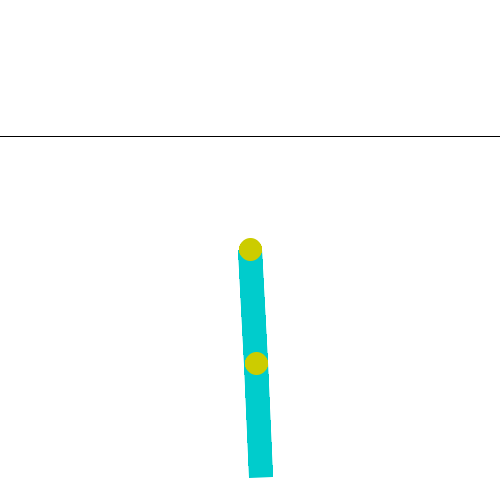

In [118]:
env_render = gym.make("Acrobot-v1", render_mode="rgb_array")
trained_policy = lambda state: agent.select_action(state, epsilon=0.0)
gif_filename = evaluate_policy(env_render, trained_policy, filename="DQN_variant_evaluation.gif")
env_render.close()
display(Image(filename=gif_filename))